# 6 — From patches to a patient prediction, and which patches drove it

The cohort is **CRC-metU** (metastatic survival) — a held-out colorectal cohort: **57 patients, 37 of whom died**, contributing 62 whole-slide regions. Four patients contributed more than one region; every readout below is per patient.

Data: **crc-metu** (`data/crc-metu`, 73 MB) — see [Tutorial 0](./00_data.ipynb).

## Step 1 — H&E → virtual MIF → features

```
H&E patch                             224 x 224 x 3 uint8
  │  QUEST                            8 predicted marker maps, [0,1]
  │  DINOv3, one marker map at a time  768-d per marker
  ▼
dino_vmif                             (T, 8, 768) float16
```

```python
from quest import QuestGenerator
from questkit import features

gen = QuestGenerator("quest-semantic")
he = ...                               # (T, 224, 224, 3) in [0,1]

f = features.patch_features(gen, he, features.PANEL8, encoder="dino")   # (T, 8, 768)
f = features.patch_features(gen, he, features.PANEL8, encoder="eva")    # (T, 768)
```

Panel: `DAPI, CD3e, CD8, CD20, CD68, Ki67, PDL1, PanCK` — the 8 every compared stainer produces.
`feats/` in the staged cohort is this call over each slide's patches.

## Step 2 — aggregation on two axes

Both are learned.

**Markers, within a patch.** The `(8, 768)` embeddings are concatenated to 6,144-d and mixed by
`Linear(6144 → 192) → LayerNorm → GELU → Dropout`. `--markers` swaps in a learned query over the 8
markers instead; marker importance is measured by re-fitting without a marker, not by reading a
weight.

**Patches, within a patient.** The gated attention pool of Step 3.
`questkit.aggregate.aggregate` is the fixed-summary path for non-MIL readouts.

## Step 3 — the MIL

$$a = \mathrm{softmax}\!\big(w^{\top}\,[\tanh(Vh) \odot \sigma(Uh)]\big), \qquad z = \sum_i a_i h_i$$

### The commands

```
reads   data/crc-metu/feats/slide####.npz     dino_vmif (T, 8, 768) + panel
        data/crc-metu/slide_index.json        slide_idx -> patient_id
        data/crc-metu/labels.csv              patient_id, survival_metU, os_event_metU
writes  data/crc-metu/mil_oof_metU_rerun.json
```

```bash
python -m questkit.mil_survival                  # or: python questkit/mil_survival.py
python -m questkit.mil_survival --markers        # marker attention instead of the projection
python -m questkit.mil_survival --head linear
python -m questkit.mil_survival --no-loo         # skip the leave-one-out pass
```

## Step 4 — Which patches drove the prediction?

For each patch $i$,

$$\Delta\text{risk}_i = \text{risk}(\text{all patches}) - \text{risk}(\text{all patches except } i)$$

Positive pushes the patient towards higher risk, negative pulls the other way. The case is
**`hog-14210`**.

In [1]:
import _common  # noqa: F401
import numpy as np
import matplotlib.pyplot as plt

from questkit import cohort, plotting

CASE = "69T_1"                            # acquisition hog-14210
oof = cohort.load_crc_metu()
v = oof["patients"][CASE]
loo_all = np.array(v["loo_virt"])
print(f"{CASE:8s} {v['n_tiles']:3d} patches   risk {v['risk_virt']:+.2f}   "
      f"{'event' if v['event'] else 'censored'} at {v['time']:.0f} mo   "
      f"drisk range [{loo_all.min():+.3f}, {loo_all.max():+.3f}]")

69T_1     59 patches   risk +0.12   event at 32 mo   drisk range [-0.172, +0.237]


### The case

Every cell of the mosaic is one patch, and its colour is
that patch's $\Delta$risk. Red pushes risk up, blue pulls it down.

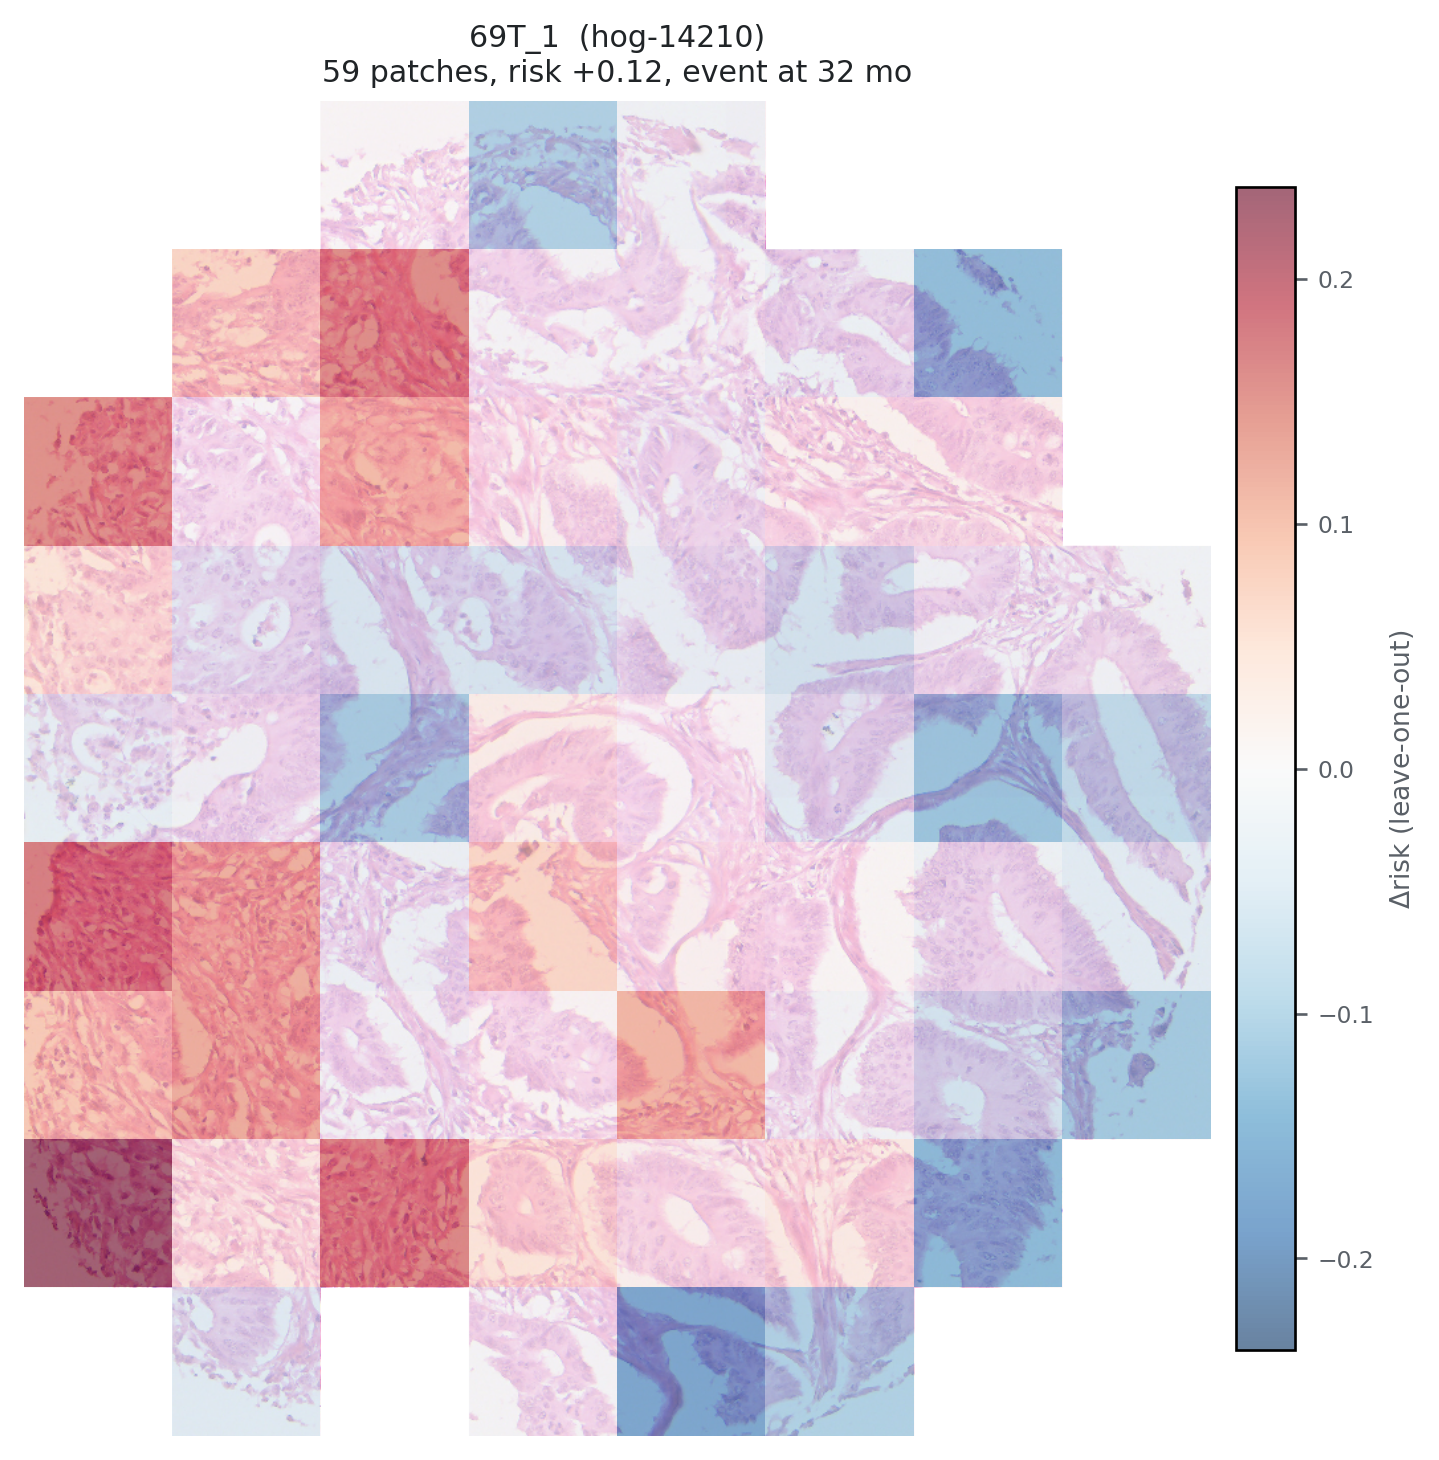

In [2]:
def overlay(ax, case, loo, alpha=0.6):
    """Stitch the case's H&E patch mosaic and paint each patch by its contribution."""
    he, coords, stride = case["he"], case["coords"], case["stride"]
    P = he.shape[1]
    rc = coords // stride
    rc = rc - rc.min(0)
    H, W = int(rc[:, 0].max()) + 1, int(rc[:, 1].max()) + 1
    mosaic = np.ones((H * P, W * P, 3), np.float32)
    heat = np.zeros((H, W), np.float32)
    covered = np.zeros((H, W), bool)
    for i, (r, c) in enumerate(rc):
        mosaic[r * P:(r + 1) * P, c * P:(c + 1) * P] = he[i] / 255.0
        heat[r, c] = loo[i]
        covered[r, c] = True

    ax.imshow(mosaic, extent=[0, W, H, 0], interpolation="bilinear")
    lim = float(np.abs(loo).max())
    im = ax.imshow(np.ma.masked_where(~covered, heat), extent=[0, W, H, 0],
                   cmap="RdBu_r", vmin=-lim, vmax=lim, alpha=alpha,
                   interpolation="nearest")
    ax.set_aspect("equal")
    plotting.bare(ax)
    return im


case = cohort.load_crc_metu_case(CASE)
loo = loo_all[:len(case["coords"])]

fig, ax = plt.subplots(figsize=(6.2, 6.2))
im = overlay(ax, case, loo)
ax.set_title(f"{CASE}  ({case['acquisition_id']})\n"
             f"{len(loo)} patches, risk {v['risk_virt']:+.2f}, "
             f"{'event' if v['event'] else 'censored'} at {v['time']:.0f} mo",
             fontsize=9, color=plotting.INK)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
cb.set_label(r"$\Delta$risk (leave-one-out)", fontsize=8, color=plotting.MUTED)
cb.ax.tick_params(labelsize=7, colors=plotting.MUTED)
fig.tight_layout()
plt.show()